# Cycling Patterns in Flanders
**Modern Data Analytics - Group 2 - KU Leuven**

In [1]:
# Auto-reload modules so edits to src/ are picked up without restart
%load_ext autoreload
%autoreload 2

# Standard imports
import gc
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

from src.loaders import load_counts, load_sites, load_directions
from src.cleaning import clean_counts, merge_with_sites, flag_outliers
from src.features import add_calendar_features, add_covid_period, add_holidays
from src.transformers import CyclicalEncoder
from src.weather import fetch_open_meteo

# Global config
RANDOM_STATE = 42
DATA_DIR = Path.cwd().parent / "data" / "raw"
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## Exploratory Data Analysis

In [2]:
processed_path = Path.cwd().parent / "data" / "processed" / "cycling_features.parquet"
df = pd.read_parquet(processed_path)
df.head()

,site_id,richting,timestamp,count,naam,lon,lat,gemeente,beheerder,paalnummer,...,is_outlier,hour,day_of_week,month,year,is_weekend,is_morning_rush,is_evening_rush,covid_period,is_holiday
0,1,IN,2019-08-01 00:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,False,0,3,8,2019,False,False,False,pre_covid,False
1,1,IN,2019-08-01 01:00:00,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,False,1,3,8,2019,False,False,False,pre_covid,False
2,1,IN,2019-08-01 02:00:00,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,False,2,3,8,2019,False,False,False,pre_covid,False
3,1,IN,2019-08-01 03:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,False,3,3,8,2019,False,False,False,pre_covid,False
4,1,IN,2019-08-01 04:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,False,4,3,8,2019,False,False,False,pre_covid,False


In [3]:
from src.plots import (
    plot_hourly_profile,
    plot_monthly_seasonality,
    plot_yearly_trend,
    plot_dayofweek_profile,
    plot_heatmap_top_site,
    plot_top_gemeenten,
    plot_site_map,
)

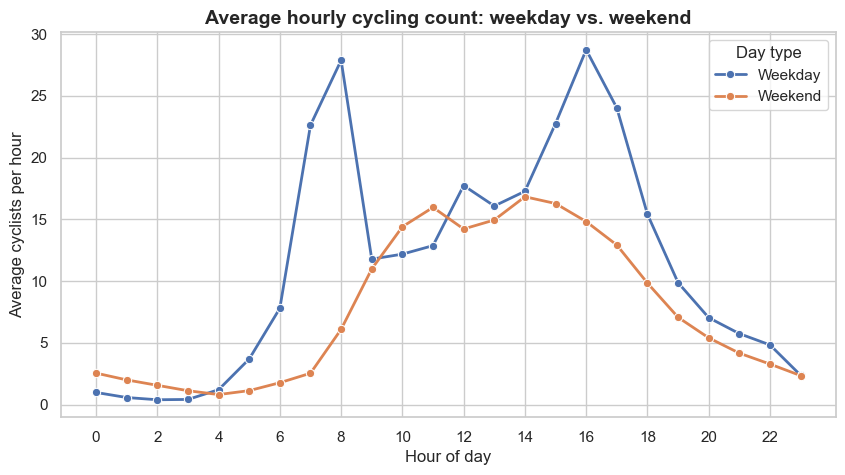

c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profile, x="day_of_week", y="count", ax=ax,
c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


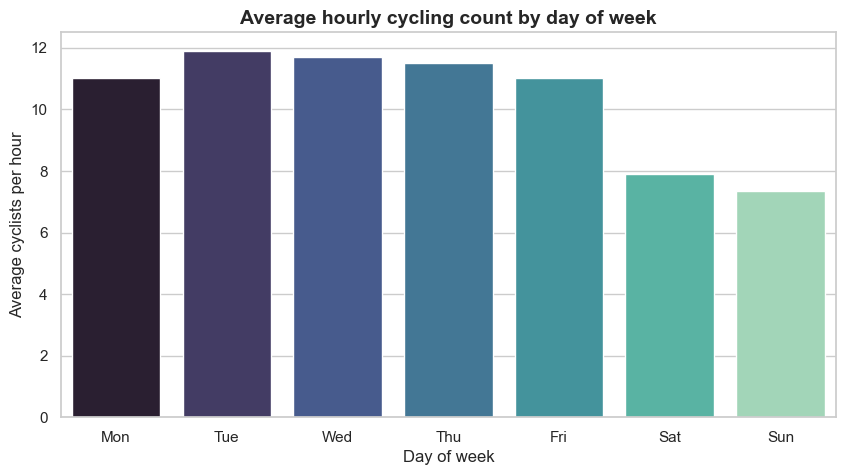

In [4]:
plot_hourly_profile(df, savepath=FIG_DIR / "hourly_profile.png")
plot_dayofweek_profile(df, savepath=FIG_DIR / "dayofweek_profile.png")

c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:32: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .sum()
c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily, x="month", y="count", ax=ax,


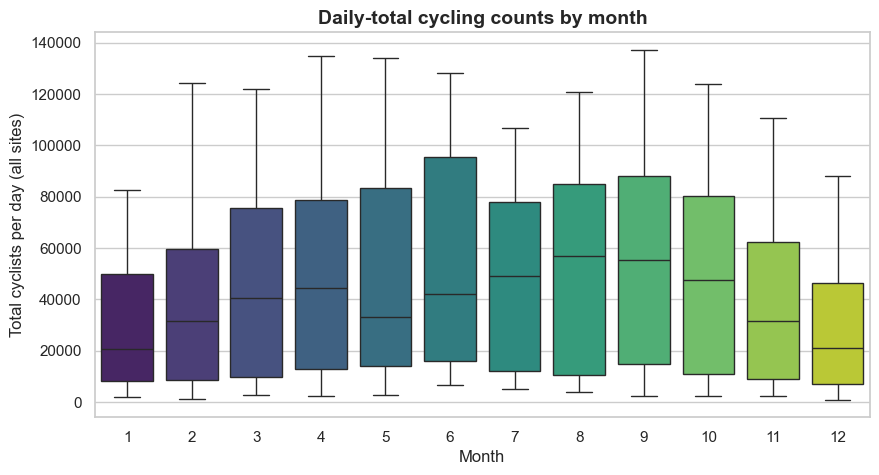

c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x="year", y="count", ax=ax,


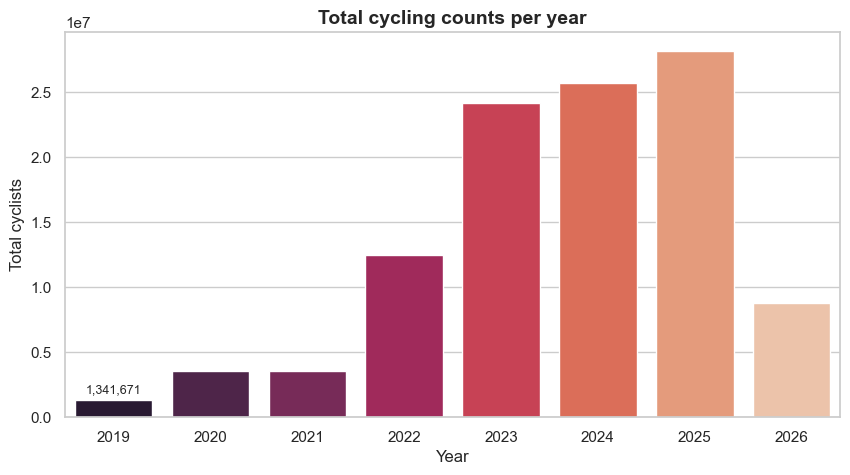

In [5]:
plot_monthly_seasonality(df, savepath=FIG_DIR / "monthly_seasonality.png")
plot_yearly_trend(df, savepath=FIG_DIR / "yearly_trend.png")

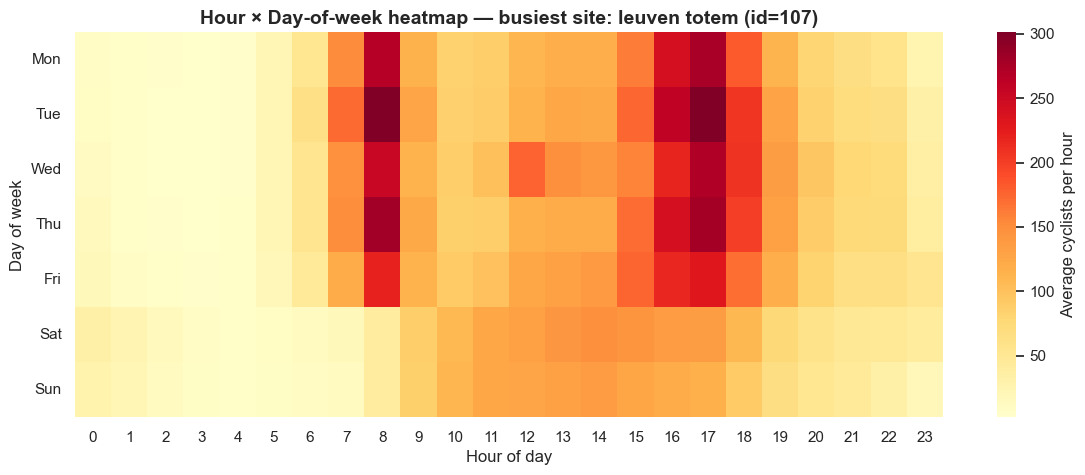

c:\Users\tobia\OneDrive\Bureaublad\Stat\sem2\Modern Data Analytics - Group 2\src\plots.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_per_gem, y="gemeente", x="avg_daily", ax=ax,


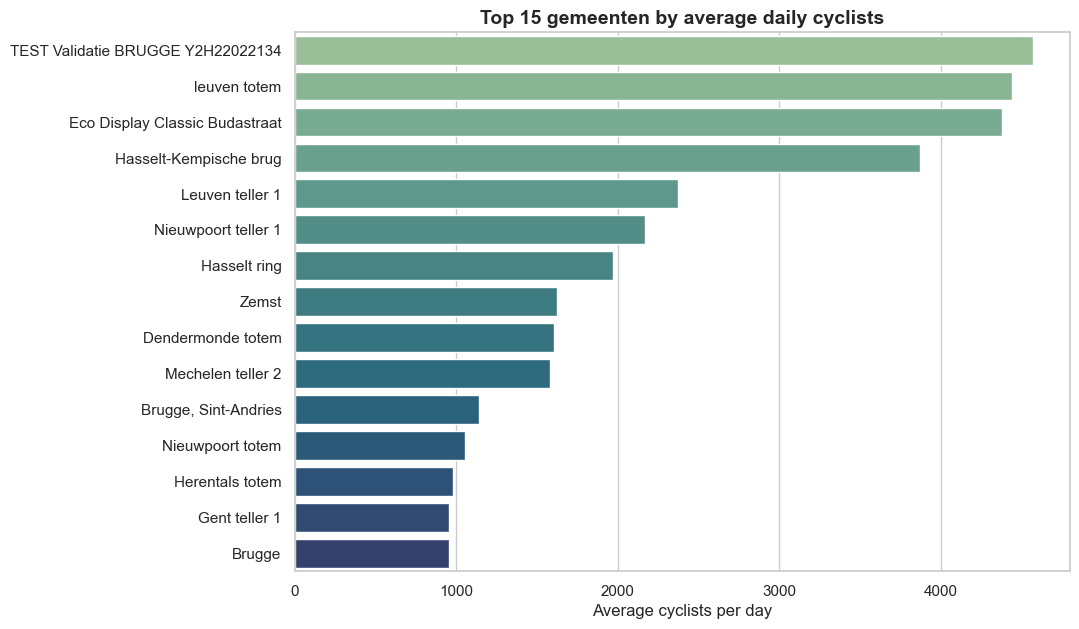

In [6]:
plot_heatmap_top_site(df, savepath=FIG_DIR / "heatmap_busiest_site.png")
plot_top_gemeenten(df, top_n=15, savepath=FIG_DIR / "top_gemeenten.png")

In [7]:
m = plot_site_map(df, top_n=50)
m.save(str(FIG_DIR / "cycling_sites_map.html"))

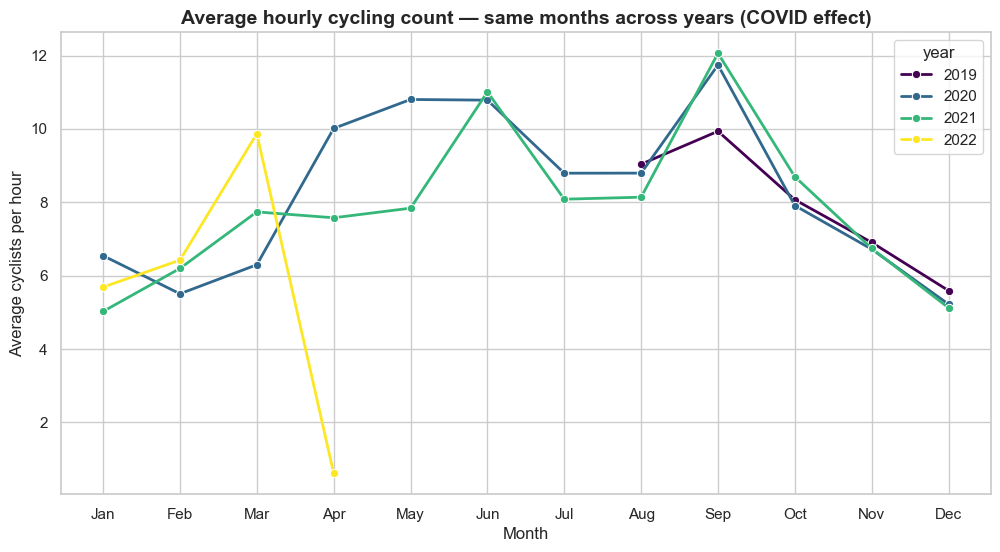

In [8]:
covid_compare = (
    df[df["timestamp"].between("2019-04-01", "2022-04-01")]
    .assign(year=lambda d: d["timestamp"].dt.year,
            month=lambda d: d["timestamp"].dt.month)
    .groupby(["year", "month"])["count"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=covid_compare, x="month", y="count", hue="year",
             marker="o", ax=ax, linewidth=2, palette="viridis")
ax.set_title("Average hourly cycling count — same months across years (COVID effect)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average cyclists per hour")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.savefig(FIG_DIR / "covid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
start_date = df["timestamp"].min().strftime("%Y-%m-%d")
end_date = df["timestamp"].max().strftime("%Y-%m-%d")

weather = fetch_open_meteo(
    lat=50.85, lon=4.35,
    start=start_date, end=end_date,
)
print(f"Fetched {len(weather):,} hourly weather observations")
weather.head()

Fetched 59,160 hourly weather observations


,timestamp,temperature_2m,precipitation,wind_speed_10m,cloud_cover
0,2019-08-01 00:00:00,15.8,0.0,11.4,48
1,2019-08-01 01:00:00,15.9,0.0,13.0,63
2,2019-08-01 02:00:00,15.9,0.0,12.1,56
3,2019-08-01 03:00:00,15.4,0.0,12.6,86
4,2019-08-01 04:00:00,15.3,0.0,13.7,76


In [10]:
df_with_weather = df.merge(weather, on="timestamp", how="left")
df_with_weather.to_parquet(PROCESSED_DIR / "cycling_with_weather.parquet", index=False)
df_with_weather.head()

,site_id,richting,timestamp,count,naam,lon,lat,gemeente,beheerder,paalnummer,...,year,is_weekend,is_morning_rush,is_evening_rush,covid_period,is_holiday,temperature_2m,precipitation,wind_speed_10m,cloud_cover
0,1,IN,2019-08-01 00:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,2019,False,False,False,pre_covid,False,15.8,0.0,11.4,48
1,1,IN,2019-08-01 01:00:00,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,2019,False,False,False,pre_covid,False,15.9,0.0,13.0,63
2,1,IN,2019-08-01 02:00:00,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,2019,False,False,False,pre_covid,False,15.9,0.0,12.1,56
3,1,IN,2019-08-01 03:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,2019,False,False,False,pre_covid,False,15.4,0.0,12.6,86
4,1,IN,2019-08-01 04:00:00,0,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,...,2019,False,False,False,pre_covid,False,15.3,0.0,13.7,76


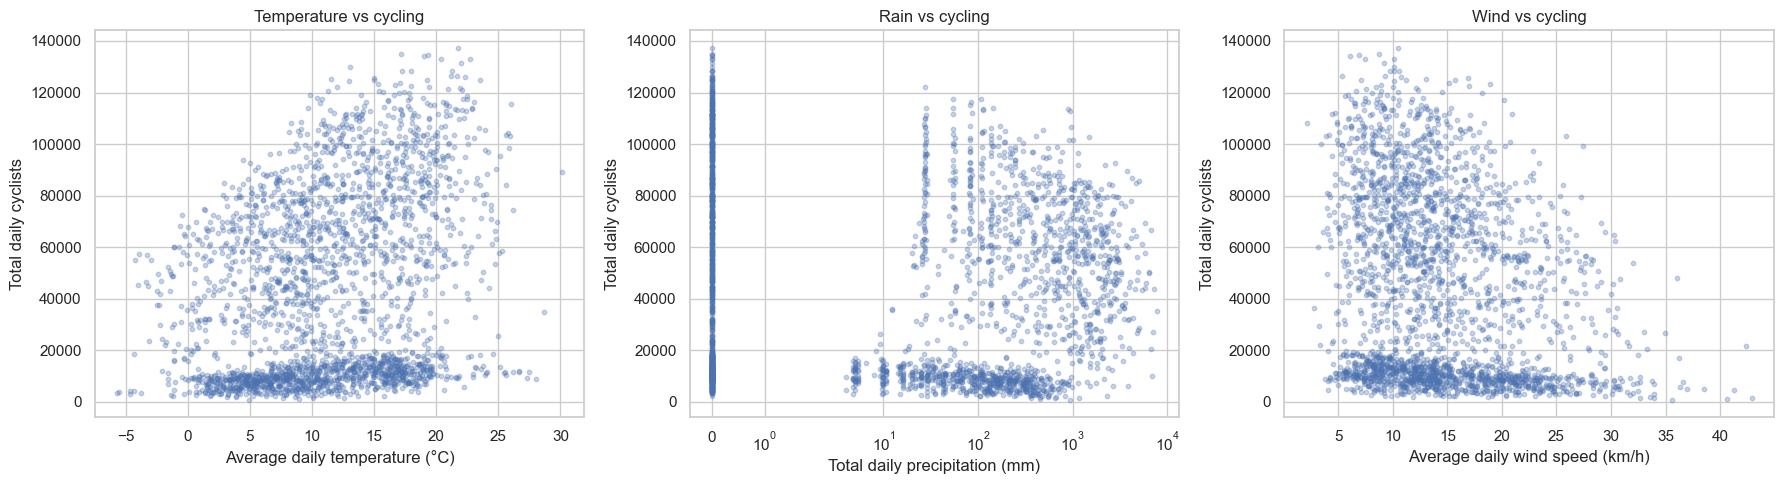

In [ ]:
daily = (
    df_with_weather
    .groupby(df_with_weather["timestamp"].dt.date)
    .agg(
        total_count=("count", "sum"),
        avg_temp=("temperature_2m", "mean"),
        total_precip=("precipitation", "sum"),
        avg_wind=("wind_speed_10m", "mean"),
    )
    .reset_index()
    .dropna()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(daily["avg_temp"], daily["total_count"], alpha=0.3, s=10)
axes[0].set_xlabel("Average daily temperature (°C)")
axes[0].set_ylabel("Total daily cyclists")
axes[0].set_title("Temperature vs cycling")

axes[1].scatter(daily["total_precip"], daily["total_count"], alpha=0.3, s=10)
axes[1].set_xlabel("Total daily precipitation (mm)")
axes[1].set_ylabel("Total daily cyclists")
axes[1].set_title("Rain vs cycling")
axes[1].set_xscale("symlog")

axes[2].scatter(daily["avg_wind"], daily["total_count"], alpha=0.3, s=10)
axes[2].set_xlabel("Average daily wind speed (km/h)")
axes[2].set_ylabel("Total daily cyclists")
axes[2].set_title("Wind vs cycling")

plt.tight_layout()
plt.savefig(FIG_DIR / "weather_correlations.png", dpi=150, bbox_inches="tight")
plt.show()